In [ ]:
!pip install torch_geometric
import os
import random
import time
import math
import copy

import torch
import torch.nn.functional as F
import torch.nn as nn
from torch_geometric.nn import GCNConv
from torch_geometric.data import Data

import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.metrics import roc_auc_score
import matplotlib.pyplot as plt

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.7/63.7 kB 4.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 71.5 MB/s eta 0:00:00


In [ ]:
if not os.path.exists("fairness-graph-gnn"):
    !git clone https://github.com/ananyabatra04/fairness-graph-gnn.git
else:
    print("fairness-graph-gnn repo already exists")

Cloning into 'fairness-graph-gnn'...
remote: Enumerating objects: 137, done.
remote: Counting objects: 100% (61/61), done.
remote: Compressing objects: 100% (51/51), done.
remote: Total 137 (delta 33), reused 13 (delta 10), pack-reused 76 (from 1)
Receiving objects: 100% (137/137), 54.51 MiB | 9.89 MiB/s, done.
Resolving deltas: 100% (47/47), done.
Updating files: 100% (30/30), done.


In [ ]:
def load_pokec_data():
    print("Loading Pokec Data...")
    nodes = pd.read_csv("fairness-graph-gnn/dataset/pokec/region_job.csv")
    nodes = nodes[nodes["I_am_working_in_field"] != -1]
    nodes["label"] = (nodes["I_am_working_in_field"] > 0).astype(int)

    feature_cols = [c for c in nodes.columns if c not in ["user_id", "region", "I_am_working_in_field", "label"]]
    X_raw = nodes[feature_cols].values
    X = torch.tensor(StandardScaler().fit_transform(X_raw), dtype=torch.float)
    y = torch.tensor(nodes["label"].values, dtype=torch.long)
    sensitive = torch.tensor((nodes["region"] == 1).astype(int).values, dtype=torch.long)

    edges = pd.read_csv(
        "fairness-graph-gnn/dataset/pokec/region_job_relationship.txt",
        sep="\t", names=["src", "dst"]
    )
    id_map = {uid: i for i, uid in enumerate(nodes["user_id"].values)}

    src_list, dst_list = [], []
    for src, dst in zip(edges["src"], edges["dst"]):
        if src in id_map and dst in id_map:
            src_list.append(id_map[src]); dst_list.append(id_map[dst])

    edge_index = torch.tensor([src_list, dst_list], dtype=torch.long)
    edge_index = torch.cat([edge_index, edge_index.flip(0)], dim=1)
    print(f"  Sensitive distribution: {sensitive.sum().item()} group=1 / {len(sensitive)} total")
    return X, edge_index, y, sensitive


def load_nba_data():
    print("Loading NBA Data...")
    nodes = pd.read_csv("fairness-graph-gnn/dataset/NBA/nba.csv")
    label_col = "SALARY"
    sens_col = "country"
    nodes = nodes[nodes[label_col] != -1].reset_index(drop=True)

    stat_features = ['AGE', 'MP', 'FG', 'FGA', 'FG%', '3P', '3PA', '3P%', '2P', '2PA', '2P%',
                     'eFG%', 'FT', 'FTA', 'FT%', 'ORB', 'DRB', 'TRB', 'AST', 'STL', 'BLK',
                     'TOV', 'PF_x', 'POINTS', 'GP', 'MPG', 'ORPM', 'DRPM', 'RPM', 'WINS_RPM',
                     'PIE', 'PACE', 'W', 'player_height', 'player_weight']
    feature_cols = [c for c in stat_features if c in nodes.columns]

    X_raw = nodes[feature_cols].values.astype(float)
    X_raw = np.nan_to_num(X_raw, nan=0.0)
    X = torch.tensor(StandardScaler().fit_transform(X_raw), dtype=torch.float)
    y = torch.tensor(nodes[label_col].values, dtype=torch.long)
    sensitive = torch.tensor(nodes[sens_col].values, dtype=torch.long)

    edges = pd.read_csv(
        "fairness-graph-gnn/dataset/NBA/nba_relationship.txt",
        sep="\t", names=["src", "dst"]
    )
    id_map = {uid: i for i, uid in enumerate(nodes["user_id"].values)}

    src_list, dst_list = [], []
    for src, dst in zip(edges["src"], edges["dst"]):
        if src in id_map and dst in id_map:
            src_list.append(id_map[src]); dst_list.append(id_map[dst])

    edge_index = torch.tensor([src_list, dst_list], dtype=torch.long)
    edge_index = torch.cat([edge_index, edge_index.flip(0)], dim=1)

    print(f"  Nodes: {X.shape[0]}, Features: {X.shape[1]}, Edges: {edge_index.shape[1]}")
    print(f"  Label distribution: {torch.bincount(y).tolist()}")
    return X, edge_index, y, sensitive

In [ ]:
# =====================================================================
# Contrastive pretraining + FairGNN
# tsipn-inspired contrastive augmentations:
#   - feature-wise fair masking (sensitive-correlation aware)
#   - optional fair edge dropout (same-group vs cross-group)
# Downstream FairGNN is intentionally kept unchanged.
# =====================================================================

def set_global_seed(seed: int):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)
    if hasattr(torch.backends, "cudnn"):
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False


@torch.no_grad()
def random_edge_drop_undirected(edge_index: torch.Tensor, p: float, generator=None):
    """Drop undirected edges with probability p, then re-expand to directed."""
    if p <= 0.0:
        return edge_index
    device = edge_index.device
    u, v = edge_index[0], edge_index[1]
    mask_upper = u < v
    undirected = edge_index[:, mask_upper]
    undirected = torch.unique(undirected, dim=1)
    E = undirected.size(1)
    keep = torch.rand(E, device=device, generator=generator) > p
    kept = undirected[:, keep]
    return torch.cat([kept, kept.flip(0)], dim=1)


@torch.no_grad()
def random_feature_drop(x: torch.Tensor, p: float, generator=None):
    """Entry-wise random masking (kept only as a baseline helper)."""
    if p <= 0.0:
        return x
    rand = torch.rand(x.shape, device=x.device, generator=generator)
    mask = rand > p
    return x * mask.float()


@torch.no_grad()
def _feature_sensitive_scores(
    x: torch.Tensor,
    sens: torch.Tensor,
    corr_type: str = "spearman",
    score_mode: str = "abs_corr",
):
    """
    Compute one sensitive-correlation score per feature column.

    score_mode:
      - "abs_corr": use |correlation|, then min-max normalize to [0,1]
      - "tsipn_pvalue": mimic tsipn's implementation style more closely
    """
    x_np = x.detach().cpu().numpy()
    s_np = sens.detach().cpu().numpy().astype(float)

    scores = []
    for j in range(x_np.shape[1]):
        feat = x_np[:, j]
        if np.std(feat) < 1e-12 or np.std(s_np) < 1e-12:
            scores.append(0.0 if score_mode == "abs_corr" else 1.0)
            continue

        if corr_type == "spearman":
            corr, pval = stats.spearmanr(feat, s_np)
        elif corr_type == "pearson":
            corr, pval = stats.pearsonr(feat, s_np)
        else:
            raise ValueError(f"Unsupported corr_type: {corr_type}")

        if np.isnan(corr):
            corr = 0.0
        if np.isnan(pval):
            pval = 1.0

        if score_mode == "abs_corr":
            scores.append(abs(float(corr)))
        elif score_mode == "tsipn_pvalue":
            # tsipn uses p-values and then (1 - pvalue) inside masking probability.
            scores.append(1.0 - float(pval))
        else:
            raise ValueError(f"Unsupported score_mode: {score_mode}")

    scores = np.asarray(scores, dtype=np.float32)
    if scores.max() > scores.min():
        scores = (scores - scores.min()) / (scores.max() - scores.min())
    else:
        scores = np.zeros_like(scores, dtype=np.float32)

    return torch.tensor(scores, dtype=torch.float32, device=x.device)


@torch.no_grad()
def fair_feature_drop_tsipn_style(
    x: torch.Tensor,
    sens: torch.Tensor,
    drop_prob: float,
    corr_type: str = "spearman",
    score_mode: str = "abs_corr",
    score_power: float = 1.0,
    generator=None,
):
    """
    tsipn-inspired feature-wise masking:
      1) score each feature by its relation to the sensitive attribute
      2) higher-score features get higher drop probability
      3) drop is column-wise (all nodes in that feature dimension are masked together)

    This is closer to the paper intent than the original notebook's entry-wise random masking.
    """
    if drop_prob <= 0.0:
        return x

    scores = _feature_sensitive_scores(
        x=x,
        sens=sens,
        corr_type=corr_type,
        score_mode=score_mode,
    )
    adjusted = torch.clamp(drop_prob * (scores ** score_power), 0.0, 1.0)
    drop_mask = torch.rand(x.size(1), device=x.device, generator=generator) < adjusted

    x_new = x.clone()
    x_new[:, drop_mask] = 0.0
    return x_new


@torch.no_grad()
def fair_edge_drop_undirected(
    edge_index: torch.Tensor,
    sens: torch.Tensor,
    p_same: float,
    p_cross: float,
    generator=None,
):
    """
    tsipn-inspired fairness-aware edge dropout on an undirected graph.

    p_same : drop probability for same-sensitive-group edges
    p_cross: drop probability for cross-sensitive-group edges

    Usually set p_same > p_cross if you want to weaken homophily by sensitive group.
    """
    if p_same <= 0.0 and p_cross <= 0.0:
        return edge_index

    device = edge_index.device
    u, v = edge_index[0], edge_index[1]
    mask_upper = u < v
    undirected = edge_index[:, mask_upper]
    undirected = torch.unique(undirected, dim=1)

    uu, vv = undirected[0], undirected[1]
    same_group = sens[uu] == sens[vv]
    drop_probs = torch.where(
        same_group,
        torch.full((undirected.size(1),), float(p_same), device=device),
        torch.full((undirected.size(1),), float(p_cross), device=device),
    )
    keep = torch.rand(undirected.size(1), device=device, generator=generator) > drop_probs
    kept = undirected[:, keep]
    return torch.cat([kept, kept.flip(0)], dim=1)


def info_nce_loss(z1: torch.Tensor, z2: torch.Tensor, tau: float = 0.5):
    z1 = F.normalize(z1, dim=1)
    z2 = F.normalize(z2, dim=1)
    logits12 = (z1 @ z2.T) / tau
    logits21 = (z2 @ z1.T) / tau
    labels = torch.arange(z1.size(0), device=z1.device)
    return 0.5 * (F.cross_entropy(logits12, labels) + F.cross_entropy(logits21, labels))


def group_mean_alignment_loss(z: torch.Tensor, s: torch.Tensor):
    """|| mean(z|s=0) - mean(z|s=1) ||^2"""
    s0 = (s == 0)
    s1 = (s == 1)
    if s0.sum() == 0 or s1.sum() == 0:
        return torch.tensor(0.0, device=z.device)
    m0 = z[s0].mean(dim=0)
    m1 = z[s1].mean(dim=0)
    return torch.mean((m0 - m1) ** 2)


class FairGNN_Args:
    def __init__(self, alpha=4.0, beta=0.01, lr=0.001, weight_decay=5e-4,
                 num_hidden=128, dropout=0.6, acc_thresh=0.5, roc_thresh=0.0):
        self.alpha = alpha
        self.beta = beta
        self.lr = lr
        self.weight_decay = weight_decay
        self.num_hidden = num_hidden
        self.dropout = dropout
        self.acc_thresh = acc_thresh
        self.roc_thresh = roc_thresh


class GCNEncoder(nn.Module):
    def __init__(self, in_channels, hidden_channels, out_channels, dropout=0.6):
        super().__init__()
        self.conv1 = GCNConv(in_channels, hidden_channels)
        self.conv2 = GCNConv(hidden_channels, out_channels)
        self.dropout = dropout

    def forward(self, x, edge_index):
        x = self.conv1(x, edge_index)
        x = F.relu(x)
        x = F.dropout(x, p=self.dropout, training=self.training)
        x = self.conv2(x, edge_index)
        return x


class ProjectionHead(nn.Module):
    def __init__(self, dim, proj_dim=64):
        super().__init__()
        self.fc1 = nn.Linear(dim, dim)
        self.fc2 = nn.Linear(dim, proj_dim)

    def forward(self, z):
        z = F.relu(self.fc1(z))
        return self.fc2(z)


class FairGNN_Contrastive(nn.Module):
    def __init__(self, nfeat, args, pretrained_gnn=None):
        super().__init__()
        self.args = args
        nhid = args.num_hidden
        dropout = args.dropout

        self.estimator = GCNEncoder(nfeat, nhid, 1, dropout)
        self.GNN = pretrained_gnn if pretrained_gnn is not None else GCNEncoder(nfeat, nhid, nhid, dropout)
        self.classifier = nn.Linear(nhid, 1)
        self.adv = nn.Linear(nhid, 1)

        G_params = list(self.GNN.parameters()) + list(self.classifier.parameters()) + list(self.estimator.parameters())
        self.optimizer_G = torch.optim.Adam(G_params, lr=args.lr, weight_decay=args.weight_decay)
        self.optimizer_A = torch.optim.Adam(self.adv.parameters(), lr=args.lr, weight_decay=args.weight_decay)
        self.criterion = nn.BCEWithLogitsLoss()

    def forward(self, x, edge_index):
        s = self.estimator(x, edge_index)
        z = self.GNN(x, edge_index)
        y = self.classifier(z)
        return y, s

    def optimize(self, x, edge_index, labels, idx_train, sens, idx_sens_train):
        self.train()
        self.adv.requires_grad_(False)
        self.optimizer_G.zero_grad()

        s = self.estimator(x, edge_index)
        h = self.GNN(x, edge_index)
        y = self.classifier(h)
        s_g = self.adv(h)

        s_score = torch.sigmoid(s.detach())
        s_score[idx_sens_train] = sens[idx_sens_train].unsqueeze(1).float()
        y_score = torch.sigmoid(y)

        cov = torch.abs(torch.mean((s_score - torch.mean(s_score)) * (y_score - torch.mean(y_score))))
        cls_loss = self.criterion(y[idx_train], labels[idx_train].unsqueeze(1).float())
        adv_loss = self.criterion(s_g, s_score)

        G_loss = cls_loss + self.args.alpha * cov - self.args.beta * adv_loss
        G_loss.backward()
        self.optimizer_G.step()

        self.adv.requires_grad_(True)
        self.optimizer_A.zero_grad()
        s_g = self.adv(h.detach())
        A_loss = self.criterion(s_g, s_score)
        A_loss.backward()
        self.optimizer_A.step()


def pretrain_contrastive_encoder(
    data,
    hidden_dim=64,
    dropout=0.6,
    pretrain_epochs=200,
    tau=0.5,
    p_edge=0.2,
    p_feat=0.2,
    lambda_cl_fair=0.0,
    proj_dim=64,
    lr_pretrain=0.01,
    weight_decay=5e-4,
    seed=42,
    use_fair_feature_aug=True,
    feature_corr_type="spearman",
    feature_score_mode="abs_corr",
    feature_score_power=1.0,
    view1_feat_drop=None,
    view2_feat_drop=None,
    use_fair_edge_aug=False,
    view1_same_edge_drop=None,
    view1_cross_edge_drop=None,
    view2_same_edge_drop=None,
    view2_cross_edge_drop=None,
):
    device = data.x.device
    encoder = GCNEncoder(data.num_features, hidden_dim, hidden_dim, dropout).to(device)
    projector = ProjectionHead(hidden_dim, proj_dim=proj_dim).to(device)
    optimizer = torch.optim.Adam(list(encoder.parameters()) + list(projector.parameters()),
                                 lr=lr_pretrain, weight_decay=weight_decay)
    idx_train = data.train_mask.nonzero(as_tuple=True)[0]

    view1_feat_drop = p_feat if view1_feat_drop is None else view1_feat_drop
    view2_feat_drop = p_feat if view2_feat_drop is None else view2_feat_drop
    view1_same_edge_drop = p_edge if view1_same_edge_drop is None else view1_same_edge_drop
    view1_cross_edge_drop = p_edge if view1_cross_edge_drop is None else view1_cross_edge_drop
    view2_same_edge_drop = p_edge if view2_same_edge_drop is None else view2_same_edge_drop
    view2_cross_edge_drop = p_edge if view2_cross_edge_drop is None else view2_cross_edge_drop

    for epoch in range(pretrain_epochs):
        encoder.train()
        projector.train()
        optimizer.zero_grad()

        g1 = torch.Generator(device=device); g1.manual_seed(seed * 100000 + epoch * 2 + 0)
        g2 = torch.Generator(device=device); g2.manual_seed(seed * 100000 + epoch * 2 + 1)

        if use_fair_edge_aug:
            edge_index_1 = fair_edge_drop_undirected(
                data.edge_index, data.sensitive,
                p_same=view1_same_edge_drop,
                p_cross=view1_cross_edge_drop,
                generator=g1
            )
            edge_index_2 = fair_edge_drop_undirected(
                data.edge_index, data.sensitive,
                p_same=view2_same_edge_drop,
                p_cross=view2_cross_edge_drop,
                generator=g2
            )
        else:
            edge_index_1 = random_edge_drop_undirected(data.edge_index, p_edge, generator=g1)
            edge_index_2 = random_edge_drop_undirected(data.edge_index, p_edge, generator=g2)

        if use_fair_feature_aug:
            x1 = fair_feature_drop_tsipn_style(
                data.x, data.sensitive,
                drop_prob=view1_feat_drop,
                corr_type=feature_corr_type,
                score_mode=feature_score_mode,
                score_power=feature_score_power,
                generator=g1
            )
            x2 = fair_feature_drop_tsipn_style(
                data.x, data.sensitive,
                drop_prob=view2_feat_drop,
                corr_type=feature_corr_type,
                score_mode=feature_score_mode,
                score_power=feature_score_power,
                generator=g2
            )
        else:
            x1 = random_feature_drop(data.x, view1_feat_drop, generator=g1)
            x2 = random_feature_drop(data.x, view2_feat_drop, generator=g2)

        z1 = encoder(x1, edge_index_1)
        z2 = encoder(x2, edge_index_2)
        p1 = projector(z1)
        p2 = projector(z2)

        loss_cl = info_nce_loss(p1[idx_train], p2[idx_train], tau=tau)
        loss_fair = 0.5 * (
            group_mean_alignment_loss(z1[idx_train], data.sensitive[idx_train]) +
            group_mean_alignment_loss(z2[idx_train], data.sensitive[idx_train])
        )
        loss = loss_cl + lambda_cl_fair * loss_fair
        loss.backward()
        optimizer.step()

    return encoder


def train_contrastive_fairgnn(
    data,
    args,
    epochs=200,
    seed=42,
    pretrain_epochs=200,
    tau=0.5,
    p_edge=0.2,
    p_feat=0.2,
    lambda_cl_fair=0.0,
    proj_dim=64,
    lr_pretrain=0.01,
    use_fair_feature_aug=True,
    feature_corr_type="spearman",
    feature_score_mode="abs_corr",
    feature_score_power=1.0,
    view1_feat_drop=None,
    view2_feat_drop=None,
    use_fair_edge_aug=False,
    view1_same_edge_drop=None,
    view1_cross_edge_drop=None,
    view2_same_edge_drop=None,
    view2_cross_edge_drop=None,
):
    set_global_seed(seed)
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    data = data.to(device)

    pretrained_gnn = pretrain_contrastive_encoder(
        data=data,
        hidden_dim=args.num_hidden,
        dropout=args.dropout,
        pretrain_epochs=pretrain_epochs,
        tau=tau,
        p_edge=p_edge,
        p_feat=p_feat,
        lambda_cl_fair=lambda_cl_fair,
        proj_dim=proj_dim,
        lr_pretrain=lr_pretrain,
        weight_decay=args.weight_decay,
        seed=seed,
        use_fair_feature_aug=use_fair_feature_aug,
        feature_corr_type=feature_corr_type,
        feature_score_mode=feature_score_mode,
        feature_score_power=feature_score_power,
        view1_feat_drop=view1_feat_drop,
        view2_feat_drop=view2_feat_drop,
        use_fair_edge_aug=use_fair_edge_aug,
        view1_same_edge_drop=view1_same_edge_drop,
        view1_cross_edge_drop=view1_cross_edge_drop,
        view2_same_edge_drop=view2_same_edge_drop,
        view2_cross_edge_drop=view2_cross_edge_drop,
    )

    model = FairGNN_Contrastive(
        nfeat=data.num_features,
        args=args,
        pretrained_gnn=pretrained_gnn
    ).to(device)

    idx_train = data.train_mask.nonzero(as_tuple=True)[0]
    idx_val = data.val_mask.nonzero(as_tuple=True)[0]
    idx_test = data.test_mask.nonzero(as_tuple=True)[0]
    idx_sens_train = data.sens_train_mask.nonzero(as_tuple=True)[0]

    best_result = {}
    best_fair = 100.0
    best_state = None

    for epoch in range(epochs):
        model.optimize(data.x, data.edge_index, data.y, idx_train, data.sensitive, idx_sens_train)
        model.eval()
        with torch.no_grad():
            output, _ = model(data.x, data.edge_index)

            pred_y_val = (output[idx_val].squeeze() > 0).float()
            val_y = data.y[idx_val].float()
            acc_val = (pred_y_val == val_y).float().mean().item()

            try:
                roc_val = roc_auc_score(val_y.cpu().numpy(), output[idx_val].squeeze().cpu().numpy())
            except ValueError:
                roc_val = 0.5

            sens_val = data.sensitive[idx_val]
            idx_s0_val = (sens_val == 0)
            idx_s1_val = (sens_val == 1)
            mean_s0 = pred_y_val[idx_s0_val].mean().item() if idx_s0_val.sum() > 0 else 0.0
            mean_s1 = pred_y_val[idx_s1_val].mean().item() if idx_s1_val.sum() > 0 else 0.0
            parity_val = abs(mean_s0 - mean_s1)
            if math.isnan(parity_val) or math.isnan(acc_val):
                parity_val = 1.0

            pred_y_test = (output[idx_test].squeeze() > 0).float()
            acc_test = (pred_y_test == data.y[idx_test].float()).float().mean().item()
            sens_test = data.sensitive[idx_test]
            mean_s0_test = pred_y_test[(sens_test == 0)].mean().item() if (sens_test == 0).sum() > 0 else 0.0
            mean_s1_test = pred_y_test[(sens_test == 1)].mean().item() if (sens_test == 1).sum() > 0 else 0.0
            parity_test = abs(mean_s0_test - mean_s1_test)

            true_pos_mask_test = (data.y[idx_test] == 1)
            s0_true_pos_mask = (sens_test == 0) & true_pos_mask_test
            s1_true_pos_mask = (sens_test == 1) & true_pos_mask_test
            tpr_s0_test = pred_y_test[s0_true_pos_mask].mean().item() if s0_true_pos_mask.sum() > 0 else 0.0
            tpr_s1_test = pred_y_test[s1_true_pos_mask].mean().item() if s1_true_pos_mask.sum() > 0 else 0.0
            deo_test = abs(tpr_s0_test - tpr_s1_test)

            if acc_val > args.acc_thresh and roc_val > args.roc_thresh:
                if parity_val < best_fair:
                    best_fair = parity_val
                    best_state = copy.deepcopy(model.state_dict())
                    best_result = {'epoch': epoch, 'acc': acc_test, 'parity': parity_test, 'deo': deo_test}

    if best_state is not None:
        model.load_state_dict(best_state)
    else:
        print("Warning: Model never reached Acc/ROC thresholds!")

    return best_result


In [ ]:
def make_stratified_masks(y: torch.Tensor, s: torch.Tensor, train_ratio=0.7, val_ratio=0.15, seed=0):
    y_np = y.cpu().numpy()
    s_np = s.cpu().numpy()
    strata = y_np * 2 + s_np
    idx_all = np.arange(len(y_np))

    sss1 = StratifiedShuffleSplit(n_splits=1, train_size=train_ratio, random_state=seed)
    train_idx, temp_idx = next(sss1.split(idx_all, strata))

    temp_strata = strata[temp_idx]
    val_size_rel = val_ratio / (1 - train_ratio)
    sss2 = StratifiedShuffleSplit(n_splits=1, train_size=val_size_rel, random_state=seed)
    val_rel, test_rel = next(sss2.split(temp_idx, temp_strata))

    val_idx = temp_idx[val_rel]
    test_idx = temp_idx[test_rel]

    n = len(y_np)
    train_mask = torch.zeros(n, dtype=torch.bool)
    val_mask = torch.zeros(n, dtype=torch.bool)
    test_mask = torch.zeros(n, dtype=torch.bool)
    train_mask[train_idx] = True
    val_mask[val_idx] = True
    test_mask[test_idx] = True
    return train_mask, val_mask, test_mask

In [ ]:
# =====================================================================
# Sweep: Contrastive + FairGNN
# Contrastive pretraining is now tsipn-inspired:
#   - fair feature masking by sensitive correlation
#   - optional fair edge dropout
# FairGNN downstream stage is unchanged.
# =====================================================================
DATASETS = ["nba", "pokec"]
SEEDS = list(range(0, 10))
ALPHAS = {
    "nba":   [0, 5, 10, 25, 50],
    "pokec": [0, 25, 50, 100, 200],
}

PRETRAIN_EPOCHS = {"nba": 200, "pokec": 200}
TAU = 0.5
PROJ_DIM = 64
LR_PRETRAIN = 0.01

# ---- tsipn-inspired contrastive augmentation config ----
USE_FAIR_FEATURE_AUG = True
FEATURE_CORR_TYPE = "spearman"      # tsipn default idea
FEATURE_SCORE_MODE = "abs_corr"     # cleaner than tsipn's p-value implementation
FEATURE_SCORE_POWER = 1.0           # >1 makes high-correlation features drop even more often

VIEW1_FEAT_DROP = {"nba": 0.30, "pokec": 0.30}   # close to tsipn defaults
VIEW2_FEAT_DROP = {"nba": 0.40, "pokec": 0.40}

USE_FAIR_EDGE_AUG = False           # start with feature-only; easier to debug/report
VIEW1_SAME_EDGE_DROP = {"nba": 0.20, "pokec": 0.20}
VIEW1_CROSS_EDGE_DROP = {"nba": 0.10, "pokec": 0.10}
VIEW2_SAME_EDGE_DROP = {"nba": 0.40, "pokec": 0.40}
VIEW2_CROSS_EDGE_DROP = {"nba": 0.20, "pokec": 0.20}

# Keep this small if you want fairness to mainly come from tsipn-style augmentations.
LAMBDA_CL_FAIR = {"nba": 0.25, "pokec": 0.25}

# Legacy fallback parameters kept for compatibility inside the function signatures.
P_EDGE = {"nba": 0.2, "pokec": 0.2}
P_FEAT = {"nba": 0.2, "pokec": 0.2}

all_results = []
output_file = "pyg_contrastive_fairgnn_results_tsipn_style.csv"

for ds in DATASETS:
    if ds == "pokec":
        X, edge_index, y, sensitive = load_pokec_data()
        data = Data(x=X, edge_index=edge_index, y=y)
        data.sensitive = sensitive
        epochs = 1000
        current_acc_thresh = 0.65
        current_beta = 1
    elif ds == "nba":
        X, edge_index, y, sensitive = load_nba_data()
        if y.max() > 1:
            print("Binarizing NBA salaries at the median...")
            y = (y > y.median()).to(torch.long)
        data = Data(x=X, edge_index=edge_index, y=y)
        data.sensitive = sensitive
        epochs = 500
        current_beta = 0.01
        current_acc_thresh = 0.50

    num_nodes = data.num_nodes
    print(f"\n{'='*72}")
    print(
        f"Dataset: {ds.upper()} | pretrain_epochs={PRETRAIN_EPOCHS[ds]} | "
        f"fair_feat={USE_FAIR_FEATURE_AUG} ({FEATURE_CORR_TYPE}, {FEATURE_SCORE_MODE}, power={FEATURE_SCORE_POWER}) | "
        f"view_feat=({VIEW1_FEAT_DROP[ds]}, {VIEW2_FEAT_DROP[ds]}) | "
        f"fair_edge={USE_FAIR_EDGE_AUG} | "
        f"lambda_cl_fair={LAMBDA_CL_FAIR[ds]}"
    )
    print(f"{'='*72}")

    for a in ALPHAS[ds]:
        print(f"\nStarting Sweep: Dataset={ds}, Alpha={a}")
        current_group = []

        for s in SEEDS:
            print(f"Running Seed {s}...", end=" ", flush=True)
            train_ratio = 0.7
            val_ratio = 0.15

            train_mask, val_mask, test_mask = make_stratified_masks(
                y=data.y, s=data.sensitive, train_ratio=train_ratio, val_ratio=val_ratio, seed=s
            )
            data.train_mask = train_mask
            data.val_mask = val_mask
            data.test_mask = test_mask

            train_indices = data.train_mask.nonzero(as_tuple=True)[0].cpu().numpy()
            np.random.seed(s)
            np.random.shuffle(train_indices)
            sens_train_idx = train_indices[: int(len(train_indices) * 0.5)]

            data.sens_train_mask = torch.zeros(num_nodes, dtype=torch.bool)
            data.sens_train_mask[sens_train_idx] = True

            start_time = time.time()
            args = FairGNN_Args(alpha=a, beta=current_beta, acc_thresh=current_acc_thresh, roc_thresh=0.0)

            metrics = train_contrastive_fairgnn(
                data=data,
                args=args,
                epochs=epochs,
                seed=s,
                pretrain_epochs=PRETRAIN_EPOCHS[ds],
                tau=TAU,
                p_edge=P_EDGE[ds],
                p_feat=P_FEAT[ds],
                lambda_cl_fair=LAMBDA_CL_FAIR[ds],
                proj_dim=PROJ_DIM,
                lr_pretrain=LR_PRETRAIN,
                use_fair_feature_aug=USE_FAIR_FEATURE_AUG,
                feature_corr_type=FEATURE_CORR_TYPE,
                feature_score_mode=FEATURE_SCORE_MODE,
                feature_score_power=FEATURE_SCORE_POWER,
                view1_feat_drop=VIEW1_FEAT_DROP[ds],
                view2_feat_drop=VIEW2_FEAT_DROP[ds],
                use_fair_edge_aug=USE_FAIR_EDGE_AUG,
                view1_same_edge_drop=VIEW1_SAME_EDGE_DROP[ds],
                view1_cross_edge_drop=VIEW1_CROSS_EDGE_DROP[ds],
                view2_same_edge_drop=VIEW2_SAME_EDGE_DROP[ds],
                view2_cross_edge_drop=VIEW2_CROSS_EDGE_DROP[ds],
            )

            if metrics and "acc" in metrics:
                metrics.update({
                    "dataset": ds,
                    "alpha": a,
                    "seed": s,
                    "pretrain_epochs": PRETRAIN_EPOCHS[ds],
                    "feature_corr_type": FEATURE_CORR_TYPE,
                    "feature_score_mode": FEATURE_SCORE_MODE,
                    "feature_score_power": FEATURE_SCORE_POWER,
                    "use_fair_feature_aug": USE_FAIR_FEATURE_AUG,
                    "view1_feat_drop": VIEW1_FEAT_DROP[ds],
                    "view2_feat_drop": VIEW2_FEAT_DROP[ds],
                    "use_fair_edge_aug": USE_FAIR_EDGE_AUG,
                    "view1_same_edge_drop": VIEW1_SAME_EDGE_DROP[ds],
                    "view1_cross_edge_drop": VIEW1_CROSS_EDGE_DROP[ds],
                    "view2_same_edge_drop": VIEW2_SAME_EDGE_DROP[ds],
                    "view2_cross_edge_drop": VIEW2_CROSS_EDGE_DROP[ds],
                    "lambda_cl_fair": LAMBDA_CL_FAIR[ds],
                    "time_sec": time.time() - start_time
                })
                all_results.append(metrics)
                current_group.append(metrics)
                print(f"Done! ({metrics.get('acc', 0):.4f} Acc | {metrics.get('parity', 0):.4f} ΔSP | {metrics.get('deo', 0):.4f} ΔEO)")
            else:
                print("FAILED (Model didn't return valid metrics)")

        if current_group:
            accs = [r.get('acc', 0) for r in current_group]
            dsps = [r.get('parity', 0) for r in current_group]
            deos = [r.get('deo', 0) for r in current_group]
            print(f"Mean Alpha {a}: Acc={np.mean(accs):.4f} | ΔSP={np.mean(dsps):.4f} | ΔEO={np.mean(deos):.4f}")

if all_results:
    df = pd.DataFrame(all_results)
    df.to_csv(output_file, index=False)
    print(f"\nAll experiments complete. Results saved to {output_file}")
else:
    print("\nNo results were collected.")


Loading NBA Data...
  Nodes: 313, Features: 35, Edges: 22182
  Label distribution: [154, 159]

Dataset: NBA | pretrain_epochs=200, p_edge=0.2, p_feat=0.2, lambda_cl_fair=1.0

Starting Sweep: Dataset=nba, Alpha=0
Running Seed 1... Done! (0.6984 Acc | 0.0179 ΔSP | 0.0417 ΔEO)
Running Seed 2... Done! (0.6984 Acc | 0.1157 ΔSP | 0.1250 ΔEO)
Running Seed 3... Done! (0.6667 Acc | 0.1569 ΔSP | 0.2083 ΔEO)
Running Seed 4... Done! (0.7302 Acc | 0.1157 ΔSP | 0.3333 ΔEO)
Running Seed 5... Done! (0.5397 Acc | 0.0575 ΔSP | 0.0417 ΔEO)
Running Seed 6... Done! (0.7778 Acc | 0.0519 ΔSP | 0.3333 ΔEO)
Running Seed 7... Done! (0.7460 Acc | 0.1381 ΔSP | 0.0833 ΔEO)
Running Seed 8... Done! (0.6984 Acc | 0.0384 ΔSP | 0.0833 ΔEO)
Running Seed 9... Done! (0.6825 Acc | 0.2181 ΔSP | 0.4583 ΔEO)
Mean Alpha 0: Acc=0.6931 | ΔSP=0.1011 | ΔEO=0.1898

Starting Sweep: Dataset=nba, Alpha=5
Running Seed 1... Done! (0.5397 Acc | 0.0870 ΔSP | 0.0417 ΔEO)
Running Seed 2... Done! (0.7460 Acc | 0.3045 ΔSP | 0.5417 ΔEO)
Runnin

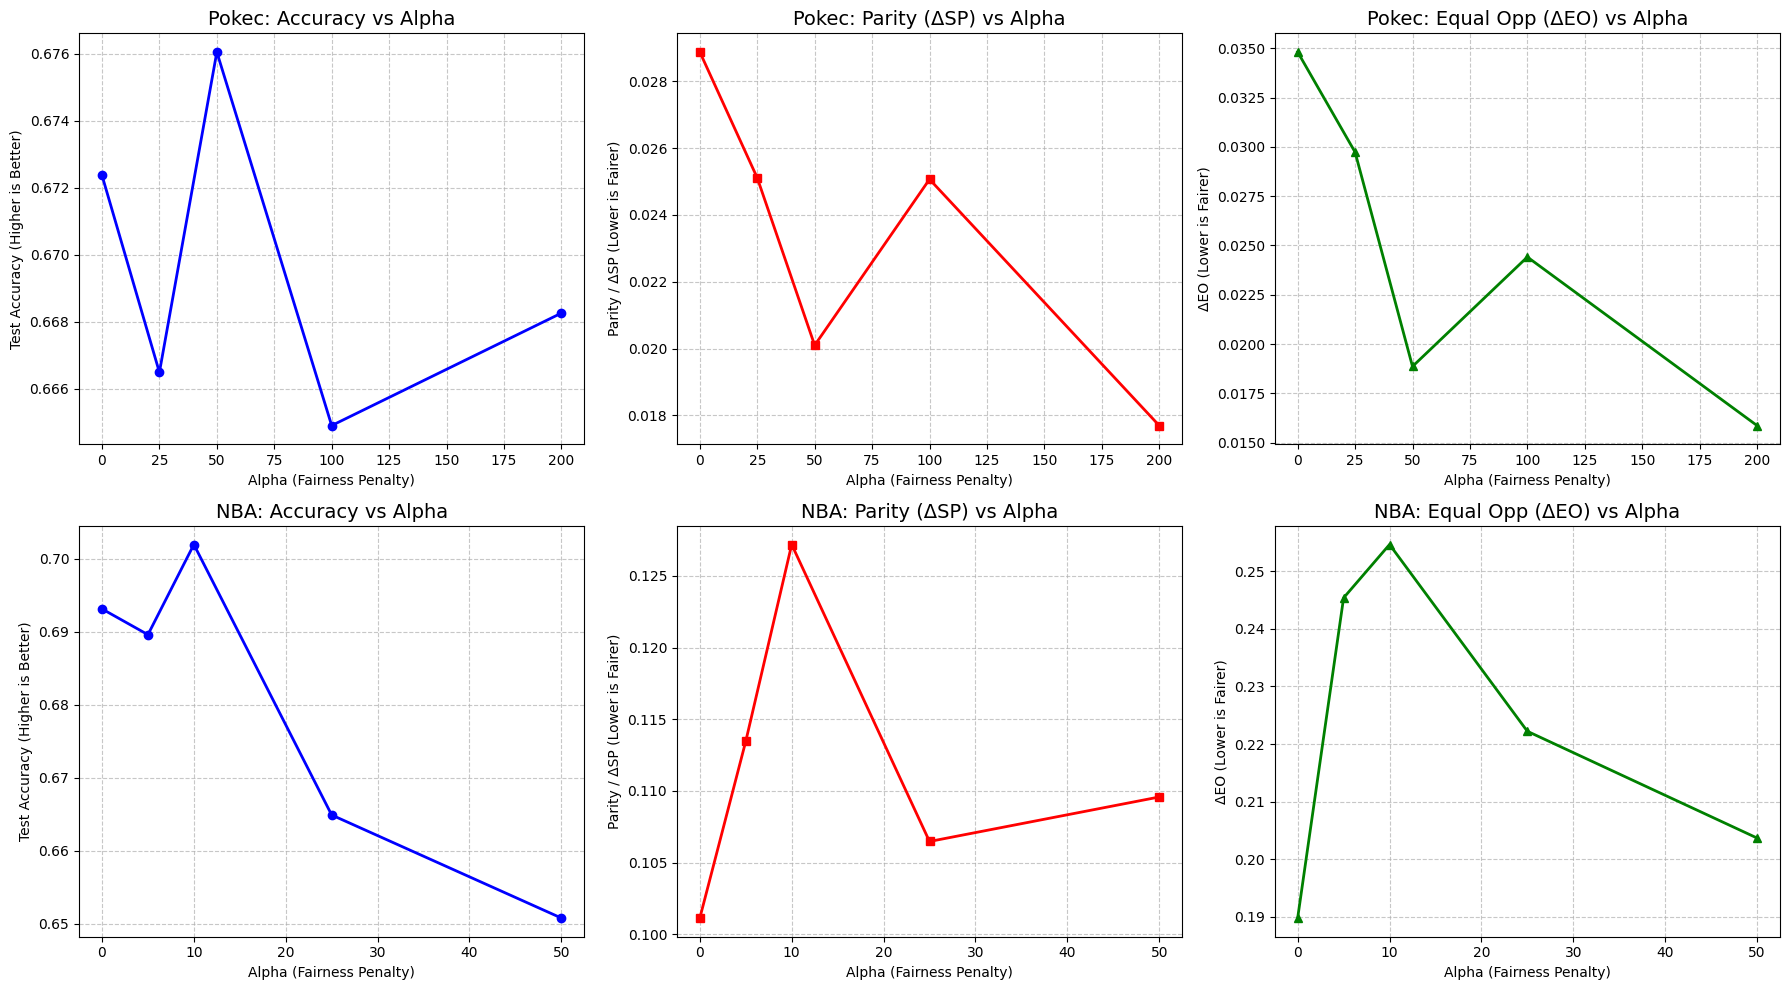

In [ ]:
df = pd.read_csv("pyg_contrastive_fairgnn_results_tsipn_style.csv")
summary = df.groupby(['dataset', 'alpha'])[['acc', 'parity', 'deo']].mean().reset_index()

pokec_data = summary[summary['dataset'] == 'pokec']
nba_data = summary[summary['dataset'] == 'nba']

fig, ((ax1, ax2, ax3), (ax4, ax5, ax6)) = plt.subplots(2, 3, figsize=(18, 10))

ax1.plot(pokec_data['alpha'], pokec_data['acc'], marker='o', color='blue', linewidth=2)
ax1.set_title("Pokec: Accuracy vs Alpha", fontsize=14)
ax1.set_xlabel("Alpha (Fairness Penalty)")
ax1.set_ylabel("Test Accuracy (Higher is Better)")
ax1.grid(True, linestyle='--', alpha=0.7)

ax2.plot(pokec_data['alpha'], pokec_data['parity'], marker='s', color='red', linewidth=2)
ax2.set_title("Pokec: Parity (ΔSP) vs Alpha", fontsize=14)
ax2.set_xlabel("Alpha (Fairness Penalty)")
ax2.set_ylabel("Parity / ΔSP (Lower is Fairer)")
ax2.grid(True, linestyle='--', alpha=0.7)

ax3.plot(pokec_data['alpha'], pokec_data['deo'], marker='^', color='green', linewidth=2)
ax3.set_title("Pokec: Equal Opp (ΔEO) vs Alpha", fontsize=14)
ax3.set_xlabel("Alpha (Fairness Penalty)")
ax3.set_ylabel("ΔEO (Lower is Fairer)")
ax3.grid(True, linestyle='--', alpha=0.7)

ax4.plot(nba_data['alpha'], nba_data['acc'], marker='o', color='blue', linewidth=2)
ax4.set_title("NBA: Accuracy vs Alpha", fontsize=14)
ax4.set_xlabel("Alpha (Fairness Penalty)")
ax4.set_ylabel("Test Accuracy (Higher is Better)")
ax4.grid(True, linestyle='--', alpha=0.7)

ax5.plot(nba_data['alpha'], nba_data['parity'], marker='s', color='red', linewidth=2)
ax5.set_title("NBA: Parity (ΔSP) vs Alpha", fontsize=14)
ax5.set_xlabel("Alpha (Fairness Penalty)")
ax5.set_ylabel("Parity / ΔSP (Lower is Fairer)")
ax5.grid(True, linestyle='--', alpha=0.7)

ax6.plot(nba_data['alpha'], nba_data['deo'], marker='^', color='green', linewidth=2)
ax6.set_title("NBA: Equal Opp (ΔEO) vs Alpha", fontsize=14)
ax6.set_xlabel("Alpha (Fairness Penalty)")
ax6.set_ylabel("ΔEO (Lower is Fairer)")
ax6.grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()